In [1]:
# ===============================
# IMPORT LIBRARY LENGKAP
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns                     # untuk confusion matrix heatmap
import warnings
warnings.filterwarnings("ignore")         # opsional agar output rapi

# Sklearn utilities
from sklearn.model_selection import StratifiedKFold, learning_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay
)
from sklearn.preprocessing import StandardScaler

# SMOTE (Borderline)
from imblearn.over_sampling import BorderlineSMOTE

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Save model
import joblib
import os


**Load Dataset**

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# Load data
file_path = '/content/drive/MyDrive/Tesis/Eksperimen/Dataset/Data Gabungan/fix_data_gabungan_fe_tambahan_2.csv'
df = pd.read_csv(file_path)

df.head()

,Hypothyroidism,Creatinine,Diabetes Mellitus (DM),Alanin Aminotransferaz (ALT),Low Density Lipoprotein (LDL),Hemoglobin (HGB),Coronary Artery Disease (CAD),Total Body Fat Ratio (TBFR) (%),Total Body Water (TBW),Height,...,Aspartat Aminotransferaz (AST),Glomerular Filtration Rate (GFR),Glucose,TC/HDL Ratio,LDL/HDL Ratio,Atherogenic Index,Triglyceride/HDL Ratio,Non-Lean Mass (NLM),Body Fat/Water Ratio,De Ritis Ratio
0,0,1.36,1,83.0,6.5,37.8,0,25.213043,36.87740,160.0,...,13.6,54.218927,130.0,6.243386,0.343915,5.243386,15.555556,-5.786957,0.683699,0.163855
1,0,0.81,0,16.0,75.0,14.3,0,13.352632,34.10012,170.0,...,25.0,94.586269,100.0,2.000000,1.000000,1.000000,0.866667,-29.647368,0.391571,1.562500
2,0,0.81,0,15.0,78.0,14.5,0,20.100000,34.67564,160.0,...,20.0,99.353543,100.0,2.083333,1.083333,1.083333,0.944444,-19.900000,0.579658,1.333333
3,0,0.81,0,14.0,78.0,15.1,0,21.885714,39.11164,170.0,...,23.0,99.353543,100.0,2.000000,1.040000,1.000000,0.866667,-8.114286,0.559570,1.642857
4,0,0.72,0,14.0,80.0,12.3,0,29.500000,26.26800,150.0,...,25.0,93.612393,98.0,2.384615,1.230769,1.384615,1.076923,-20.500000,1.123039,1.785714


In [4]:
# Target
target_col = "Gallstone Status"

X = df.drop(columns=[target_col]).values
y = df[target_col].values

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (613, 30)
Shape y: (613,)


In [5]:
# ==========================================
# PART 2 — DEFINISI SMOTE, K-FOLD & MODELS
# ==========================================
from imblearn.over_sampling import SMOTE   # <<< DIUBAH: IMPORT SMOTE BIASA

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# SMOTE
#smote = BorderlineSMOTE(random_state=42)
smote = SMOTE(random_state=42)   # <<< DIUBAH MENJADI SMOTE BIASA

# SCALER hanya untuk LR
scaler = StandardScaler()

# MODELS
models = {
    "LR": LogisticRegression(max_iter=500),
    "RF": RandomForestClassifier(n_estimators=300, random_state=42),
    "XGB": XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        random_state=42, eval_metric="logloss"
    ),
    "LGBM": LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        random_state=42
    )
}

# Print parameter untuk dokumentasi
for name, m in models.items():
    print(f"\n=== PARAMETER {name} ===")
    print(m.get_params())

from copy import deepcopy
base_models = {name: deepcopy(model) for name, model in models.items()}



=== PARAMETER LR ===
{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 500, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

=== PARAMETER RF ===
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 300, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

=== PARAMETER XGB ===
{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical':

In [6]:
# ======================================================
# PART 3 — TRAIN & TEST CV (10-FOLD) + SMOTE di TRAIN FOLD
# ======================================================

metrics_result = {m: [] for m in models.keys()}
metrics_result["cm_list"] = {m: [] for m in models.keys()}

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n===== FOLD {fold} =====")

    # ===========================
    # Split data per fold
    # ===========================
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # ===========================
    # SMOTE hanya di TRAIN
    # ===========================
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # ===========================
    # Loop semua model
    # ===========================
    for name, model in models.items():

        # ===========================
        # Scaling KHUSUS LR
        # ===========================
        if name == "LR":
            X_train_scaled = scaler.fit_transform(X_train_res)
            X_test_scaled  = scaler.transform(X_test)

            model.fit(X_train_scaled, y_train_res)
            y_pred = model.predict(X_test_scaled)
            y_proba = model.predict_proba(X_test_scaled)[:, 1]

        else:
            model.fit(X_train_res, y_train_res)
            y_pred = model.predict(X_test)
            y_proba = model.predict_proba(X_test)[:, 1]

        # ===========================
        # METRIK
        # ===========================
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)

        metrics_result[name].append([acc, prec, rec, f1, auc])

        # SIMPAN CONFUSION MATRIX PER FOLD
        cm = confusion_matrix(y_test, y_pred)
        metrics_result["cm_list"][name].append(cm)

        print(f"{name} — Fold {fold}: Acc={acc:.3f}, AUC={auc:.3f}")



===== FOLD 1 =====
LR — Fold 1: Acc=0.839, AUC=0.942
RF — Fold 1: Acc=0.839, AUC=0.908
XGB — Fold 1: Acc=0.839, AUC=0.912
[LightGBM] [Info] Number of positive: 406, number of negative: 406
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000374 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6103
[LightGBM] [Info] Number of data points in the train set: 812, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [7]:
# ================================================
# PART 4 — REKAP RATA-RATA HASIL SETIAP CLASSIFIER (TABEL)
# ================================================

import pandas as pd
import numpy as np

rows = []

for name, scores in metrics_result.items():

    if name == "cm_list":
        continue  # LEWATI CONFUSION MATRIX

    mean_scores = np.mean(scores, axis=0)

    rows.append({
        "Model": name,
        "Accuracy": round(mean_scores[0], 4),
        "Precision": round(mean_scores[1], 4),
        "Recall": round(mean_scores[2], 4),
        "F1-Score": round(mean_scores[3], 4),
        "ROC-AUC": round(mean_scores[4], 4)
    })

# Buat DataFrame
df_results = pd.DataFrame(rows)

# Tampilkan
print("\n======= HASIL CV (MEAN 10 FOLD) =======")
display(df_results)



======= HASIL CV (MEAN 10 FOLD) =======


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,LR,0.7780,0.5547,0.8022,0.6545,0.8432
1,RF,0.7700,0.5554,0.6533,0.5971,0.8569
2,XGB,0.7960,0.6126,0.6401,0.6226,0.8615
3,LGBM,0.7699,0.5567,0.6088,0.5799,0.8521



===== MEAN CONFUSION MATRIX (10 Fold) =====


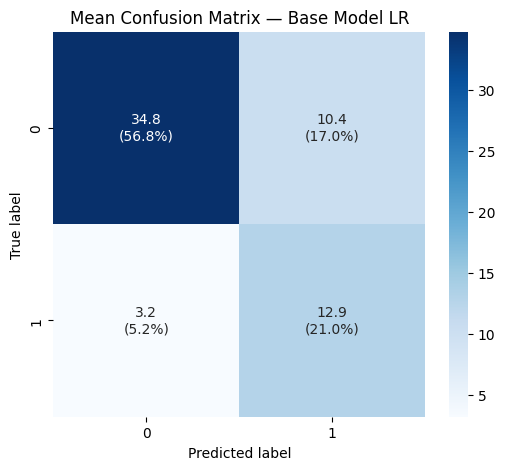

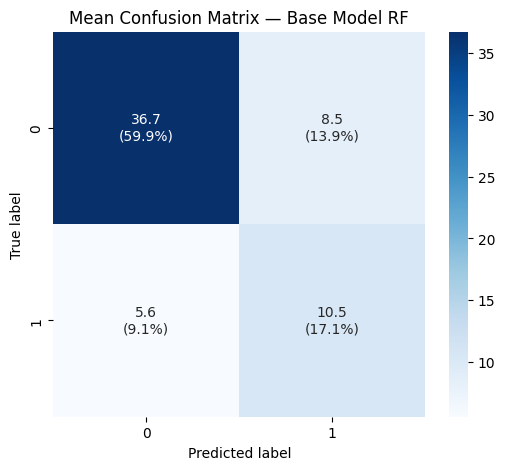

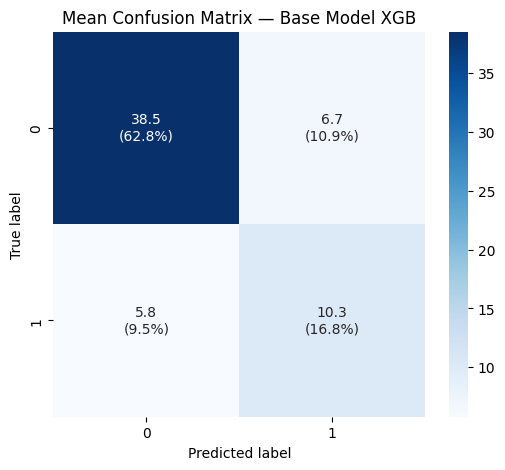

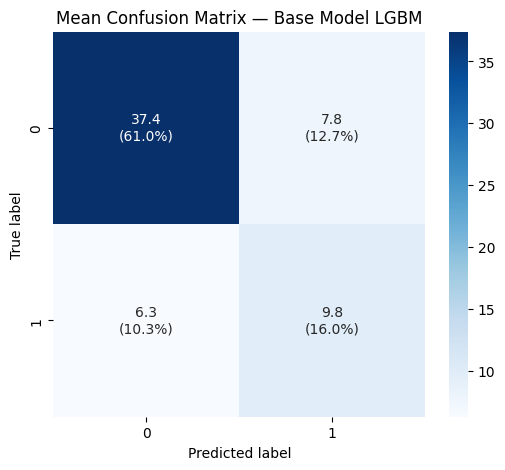

In [8]:
# ============================================
# PART 5 — MEAN CONFUSION MATRIX (1 per figure)
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n===== MEAN CONFUSION MATRIX (10 Fold) =====")

for name in models.keys():

    # Ambil semua confusion matrix dari 10 fold
    cm_all = metrics_result["cm_list"][name]

    # Mean confusion matrix
    cm_mean = np.mean(cm_all, axis=0)

    # Persentase (%)
    cm_percent = (cm_mean / cm_mean.sum()) * 100

    # Gabungan Value + Persen
    annot = np.empty_like(cm_mean).astype(str)
    for r in range(cm_mean.shape[0]):
        for c in range(cm_mean.shape[1]):
            annot[r, c] = f"{cm_mean[r, c]:.1f}\n({cm_percent[r, c]:.1f}%)"

    # === Plot per model ===
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_mean, annot=annot, fmt="", cmap="Blues")
    plt.title(f"Mean Confusion Matrix — Base Model {name}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.show()


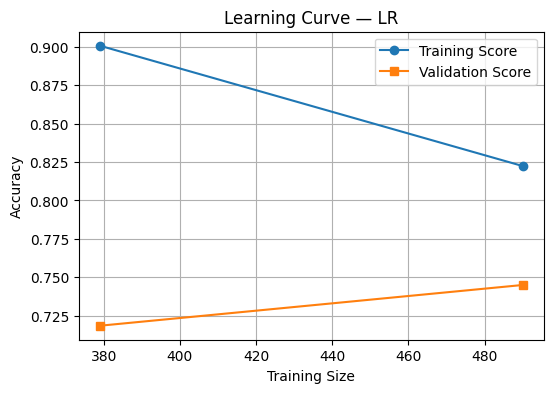

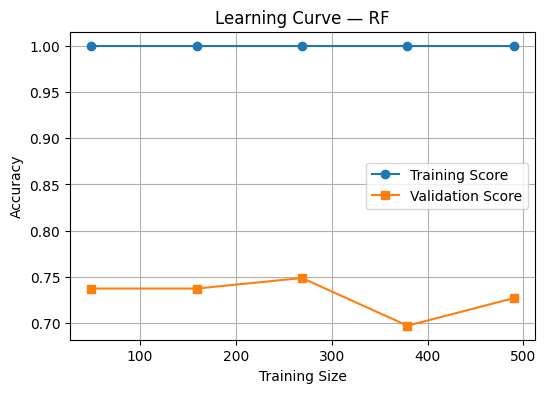

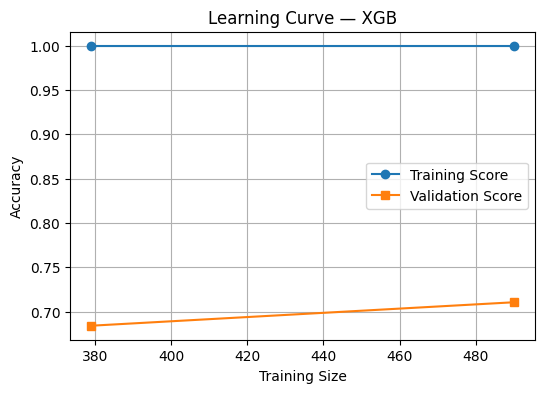

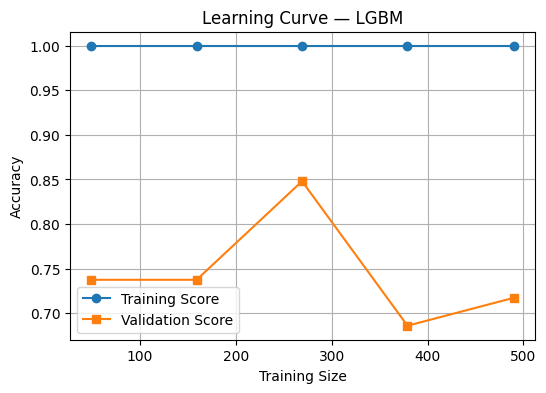

In [9]:
# ============================================
# PART 6 — LEARNING CURVE
# ============================================

def plot_learning(model, name, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator=model,
        X=X, y=y,
        cv=5,
        scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(6,4))
    plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
    plt.plot(train_sizes, test_mean, marker='s', label='Validation Score')
    plt.title(f"Learning Curve — {name}")
    plt.xlabel("Training Size")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()


# Jalankan learning curve
for name, model in base_models.items():

    # scaling khusus LR
    if name == "LR":
        X_scaled = scaler.fit_transform(X)
        plot_learning(model, name, X_scaled, y)
    else:
        plot_learning(model, name, X, y)


<Figure size 700x600 with 0 Axes>

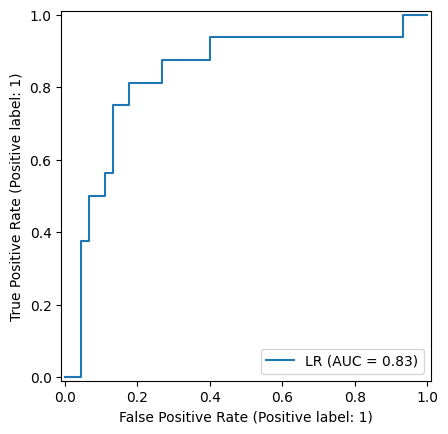

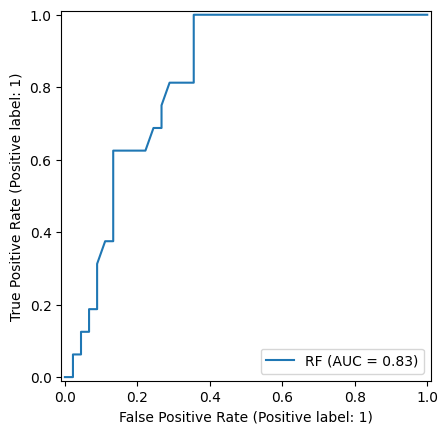

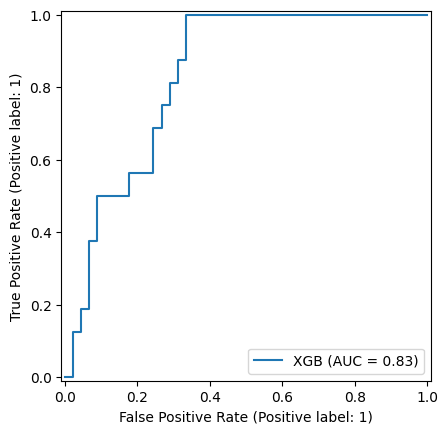

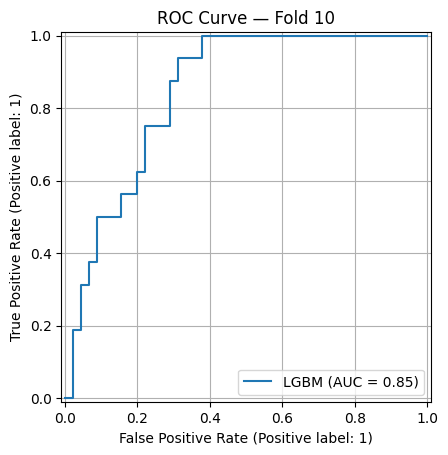

In [10]:
    # =====================================================
    # ROC CURVE PER MODEL PER FOLD + CAPTION AUC
    # =====================================================
    plt.figure(figsize=(7, 6))

    for name, model in models.items():

        # scaling khusus LR
        if name == "LR":
            X_test_scaled = scaler.transform(X_test)
            y_proba_fold = model.predict_proba(X_test_scaled)[:, 1]
        else:
            y_proba_fold = model.predict_proba(X_test)[:, 1]

        # Hitung AUC
        auc_score = roc_auc_score(y_test, y_proba_fold)

        # Plot ROC + caption
        RocCurveDisplay.from_predictions(
            y_test,
            y_proba_fold,
            name=f"{name}"# (AUC = {auc_score:.3f})"
        )

    plt.title(f"ROC Curve — Fold {fold}")
    plt.grid(True)

    # Simpan ke drive (opsional)
    #save_dir = "/content/drive/MyDrive/Tesis/ROC_Fold_Plots"
    #os.makedirs(save_dir, exist_ok=True)
    #plt.savefig(f"{save_dir}/roc_fold_{fold}.png", dpi=200)

    plt.show()


In [11]:
# ============================================
# OUTPUT DIRECTORY UNTUK MENYIMPAN MODEL
# ============================================
output_dir = "/content/drive/MyDrive/Tesis/Fix FE CV/Classic Clasifiers/Base Model/"
os.makedirs(output_dir, exist_ok=True)


In [12]:
# =====================================================
# PART 7 — TRAIN FINAL MODEL (FULL DATA) & SAVE MODEL
# =====================================================

print("\n===== TRAIN FINAL MODEL & SAVE =====")

# SMOTE pada full data
X_res, y_res = smote.fit_resample(X, y)

for name, model in base_models.items():

    print(f"Saving model: {name}")

    if name == "LR":
        # Scaling untuk Logistic Regression
        X_res_scaled = scaler.fit_transform(X_res)

        model.fit(X_res_scaled, y_res)

        # Simpan scaler + model
        joblib.dump(
            {
                "scaler": scaler,
                "model": model
            },
            os.path.join(output_dir, f"{name}_final_model.pkl")
        )

    else:
        model.fit(X_res, y_res)

        joblib.dump(
            model,
            os.path.join(output_dir, f"{name}_final_model.pkl")
        )

print("\n✅ Semua model berhasil disimpan ke:")
print(output_dir)



===== TRAIN FINAL MODEL & SAVE =====
Saving model: LR
Saving model: RF
Saving model: XGB
Saving model: LGBM
[LightGBM] [Info] Number of positive: 452, number of negative: 452
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000248 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6156
[LightGBM] [Info] Number of data points in the train set: 904, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

In [13]:
import numpy as np
import pandas as pd
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline   # penting!

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


In [14]:
#agar tidak overfitting
param_space = {
    "LR": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__solver": ["lbfgs", "liblinear"],
        "model__penalty": ["l1", "l2"],
        "model__class_weight": [None, "balanced"]
    },

    "RF": {
        "model__n_estimators": [200, 300, 400],
        "model__max_depth": [5, 8, 12],           # Batasi untuk mencegah overfit
        "model__min_samples_split": [5, 10, 15],  # Lebih besar → hindari split ekstrem
        "model__min_samples_leaf": [3, 5, 7],     # Lebih besar → hindari leaf kecil
        "model__max_features": ["sqrt", 0.5, 0.7],# Ambil subset fitur → regularisasi
        "model__class_weight": ["balanced"]       # Untuk data tidak seimbang
    },

      "XGB": {
        "model__n_estimators": [100, 150, 200, 250],
        "model__learning_rate": [0.01, 0.02, 0.03],    # Lebih kecil → slow learning
        "model__max_depth": [3, 4],                    # Batasi kedalaman
        "model__subsample": [0.6, 0.7],               # Random sampling → anti-overfit
        "model__colsample_bytree": [0.6, 0.7],        # Random feature sampling
        "model__reg_alpha": [0.5, 1],                 # L1 regularization
        "model__reg_lambda": [2, 3],                  # L2 regularization
        "model__scale_pos_weight": [1, 3, 5]          # Jika data tidak seimbang
    },

    "LGBM": {
        "model__n_estimators": [200, 300],
        "model__learning_rate": [0.005, 0.01],        # Sangat kecil → stabil
        "model__max_depth": [3, 5],                   # Batasi kedalaman
        "model__num_leaves": [5, 7, 15],              # Sesuai max_depth
        "model__min_child_samples": [20, 30, 40],     # Cegah leaf kecil → overfit
        "model__subsample": [0.6, 0.7],               # Random sampling
        "model__colsample_bytree": [0.6, 0.7],        # Random fitur
        "model__reg_alpha": [0.1, 0.3, 0.5],          # L1 regularization
        "model__reg_lambda": [1.0, 2.0, 3.0],         # L2 regularization
        "model__min_split_gain": [0.05, 0.1]          # Threshold split → regularisasi
    }
}


In [15]:
base_models = {
    "LR": LogisticRegression(max_iter=500),
    "RF": RandomForestClassifier(random_state=42),
    "XGB": XGBClassifier(eval_metric="logloss", random_state=42),
    "LGBM": LGBMClassifier(random_state=42)
}


In [16]:
def make_pipeline(model_name, model):
    if model_name == "LR":
        # LR pakai scaler
        pipe = ImbPipeline([
            ("smote", SMOTE(random_state=42)),
            ("scaler", StandardScaler()),
            ("model", model)
        ])
    else:
        # Model lain tanpa scaler
        pipe = ImbPipeline([
            ("smote", SMOTE(random_state=42)),
            ("model", model)
        ])
    return pipe


In [17]:
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
best_models = {}

for name, base_model in base_models.items():
    print(f"\n=========== RANDOM SEARCH TUNING — {name} ===========")

    pipe = make_pipeline(name, base_model)

    rand_search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_space[name],
        n_iter=10,
        scoring="roc_auc",
        cv=kf,
        random_state=42,
        n_jobs=-1
    )

    rand_search.fit(X, y)

    best_models[name] = rand_search.best_estimator_

    print("Best Params:", rand_search.best_params_)
    print("Best CV AUC:", rand_search.best_score_)



=========== RANDOM SEARCH TUNING — LR ===========
Best Params: {'model__solver': 'lbfgs', 'model__penalty': 'l2', 'model__class_weight': 'balanced', 'model__C': 10}
Best CV AUC: 0.8430967604433077

=========== RANDOM SEARCH TUNING — RF ===========
Best Params: {'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': 12, 'model__class_weight': 'balanced'}
Best CV AUC: 0.8605997797669793

=========== RANDOM SEARCH TUNING — XGB ===========
Best Params: {'model__subsample': 0.7, 'model__scale_pos_weight': 1, 'model__reg_lambda': 3, 'model__reg_alpha': 1, 'model__n_estimators': 200, 'model__max_depth': 4, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.7}
Best CV AUC: 0.8666313228189827

=========== RANDOM SEARCH TUNING — LGBM ===========
[LightGBM] [Info] Number of positive: 452, number of negative: 452
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.0002


===== FINAL EVALUASI — LR =====
Accuracy: 0.8197
Precision: 0.6190
Recall: 0.8125
F1: 0.7027
AUC: 0.8583


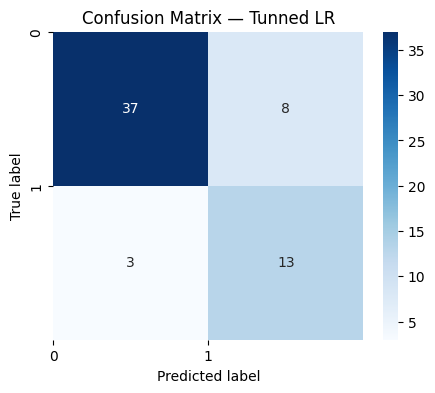

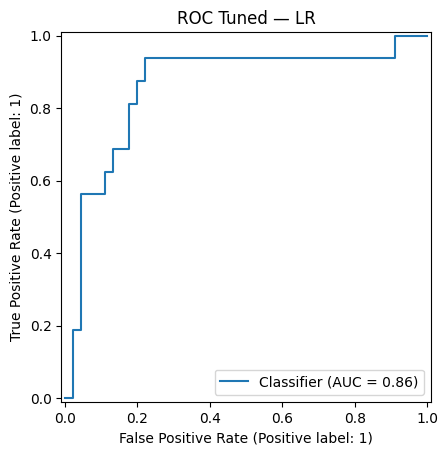


===== FINAL EVALUASI — RF =====
Accuracy: 0.8852
Precision: 0.7143
Recall: 0.9375
F1: 0.8108
AUC: 0.9819


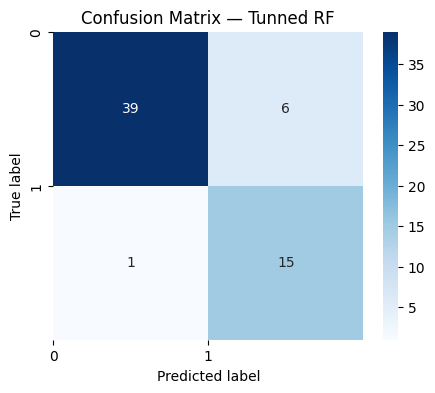

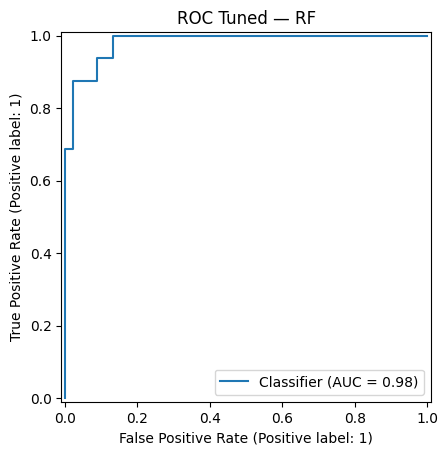


===== FINAL EVALUASI — XGB =====
Accuracy: 0.8689
Precision: 0.7222
Recall: 0.8125
F1: 0.7647
AUC: 0.9597


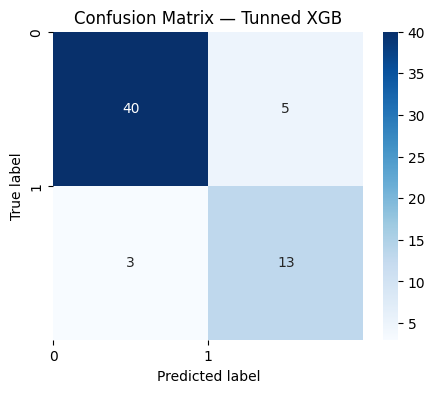

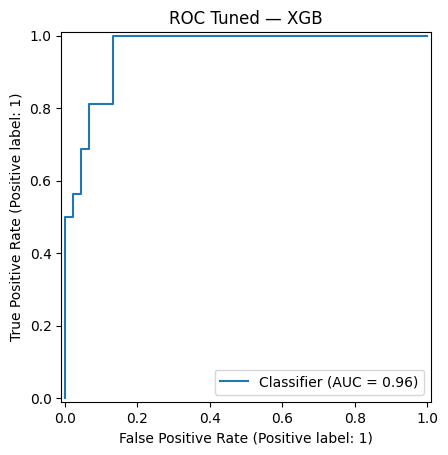


===== FINAL EVALUASI — LGBM =====
Accuracy: 0.8525
Precision: 0.6667
Recall: 0.8750
F1: 0.7568
AUC: 0.9250


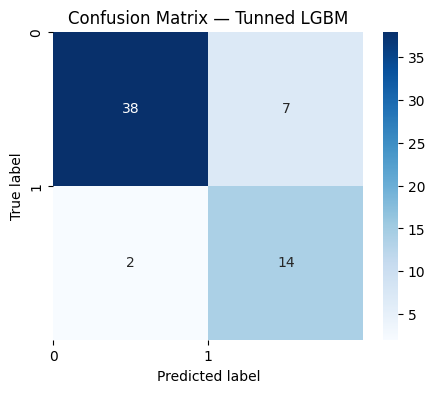

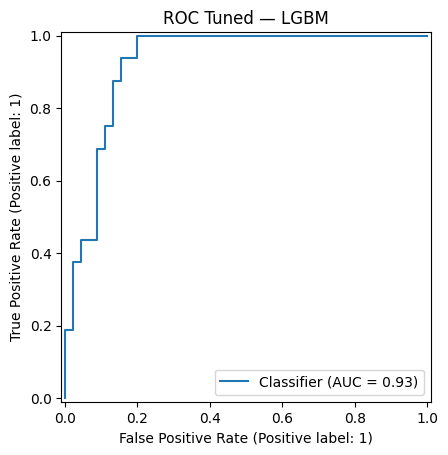

In [18]:
results = []

for name, model in best_models.items():
    print(f"\n===== FINAL EVALUASI — {name} =====")

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)

    results.append([name, acc, prec, rec, f1, auc])

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"AUC: {auc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.title(f"Confusion Matrix — Tunned {name}")
    plt.xticks([0,1], ["0","1"])
    plt.yticks([0,1], ["0","1"])
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.show()

    # ROC Curve
    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title(f"ROC Tuned — {name}")
    plt.show()



=== Learning Curve untuk LR ===


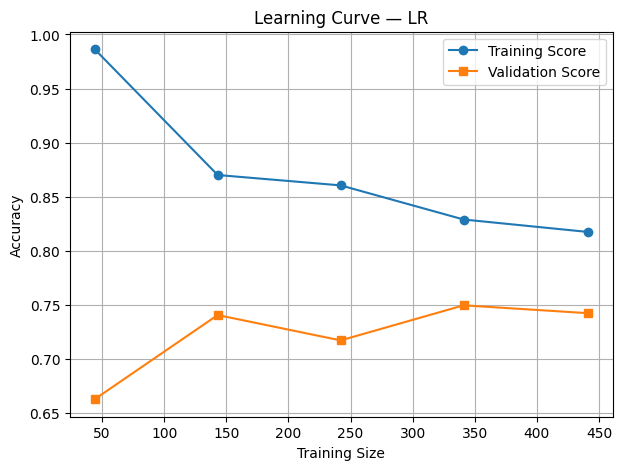


=== Learning Curve untuk RF ===


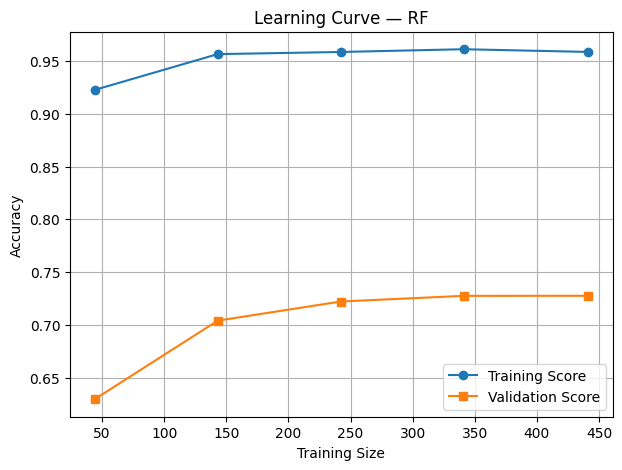


=== Learning Curve untuk XGB ===


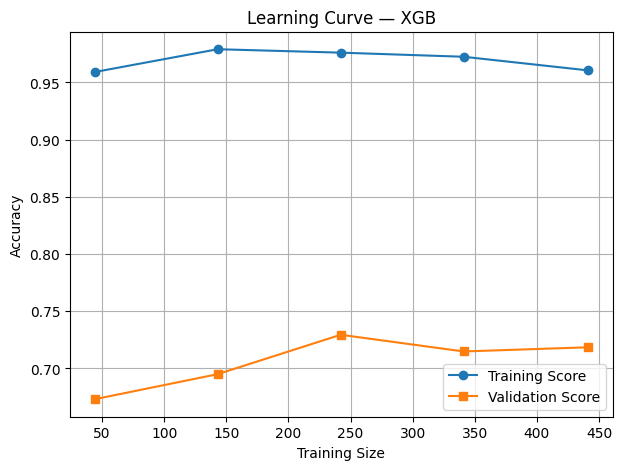


=== Learning Curve untuk LGBM ===


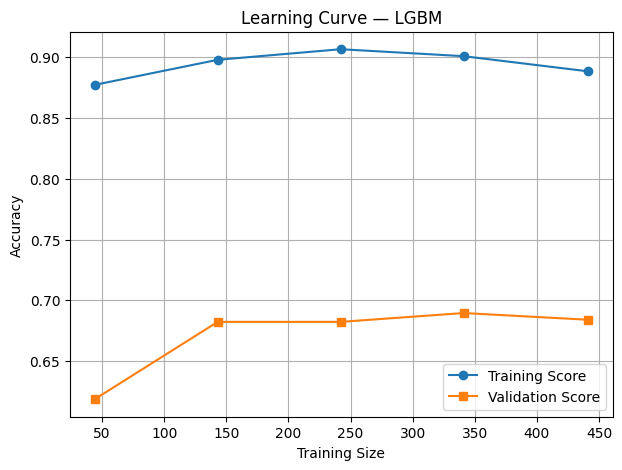

In [19]:
#leraning curve test set
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

def plot_learning_curve(model, X, y, model_name, cv=5, scoring="accuracy"):
    """
    Fungsi untuk menggambar learning curve
    """
    train_sizes, train_scores, valid_scores = learning_curve(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5),
        shuffle=True,
        random_state=42
    )

    train_mean = np.mean(train_scores, axis=1)
    valid_mean = np.mean(valid_scores, axis=1)

    plt.figure(figsize=(7,5))
    plt.plot(train_sizes, train_mean, "o-", label="Training Score")
    plt.plot(train_sizes, valid_mean, "s-", label="Validation Score")

    plt.title(f"Learning Curve — {model_name}")
    plt.xlabel("Training Size")
    plt.ylabel(scoring.capitalize())
    plt.grid(True)
    plt.legend()
    plt.show()


# ==========================================
# RUN LEARNING CURVE UNTUK SELURUH MODEL
# ==========================================
for name, model in best_models.items():
    print(f"\n=== Learning Curve untuk {name} ===")
    plot_learning_curve(model, X_train, y_train, name)



=== Learning Curve untuk LR ===


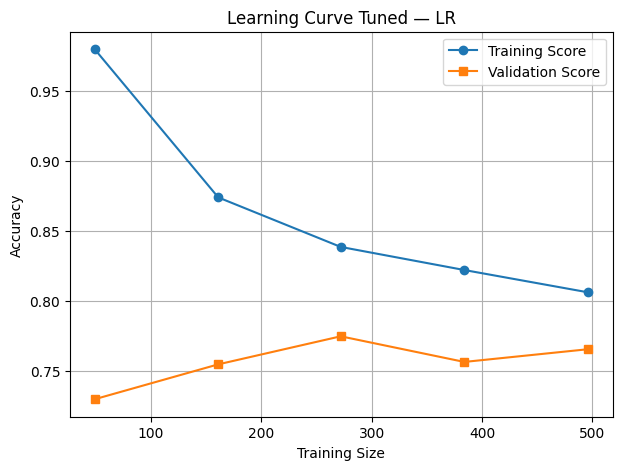


=== Learning Curve untuk RF ===


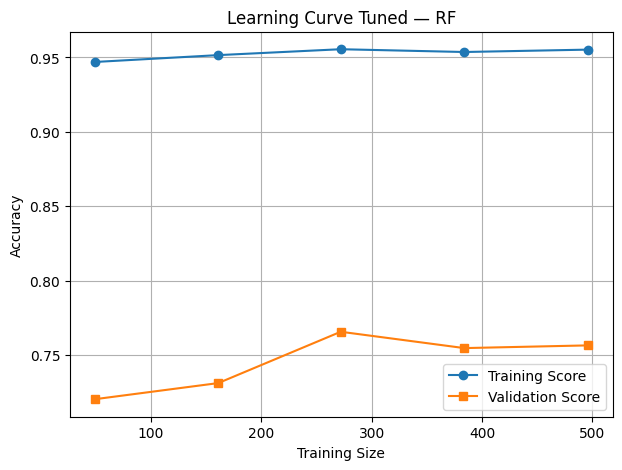


=== Learning Curve untuk XGB ===


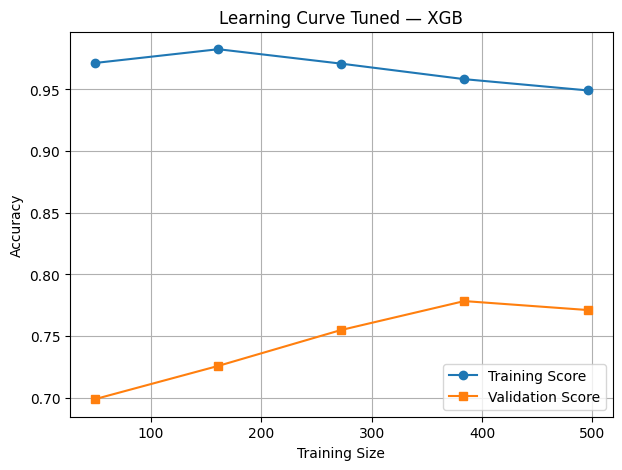


=== Learning Curve untuk LGBM ===


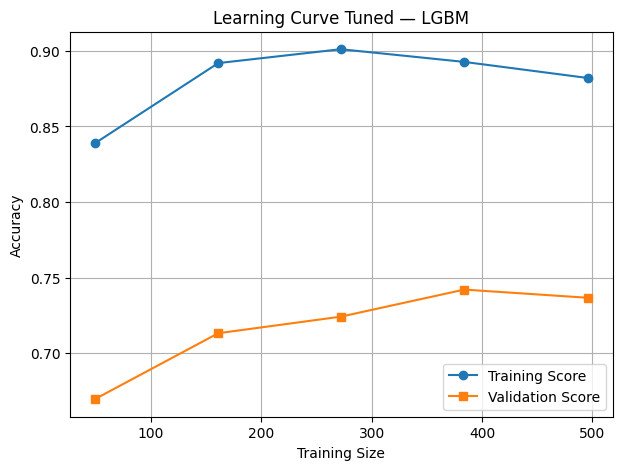

In [20]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

def plot_learning_curve(model, X, y, model_name, cv=10, scoring="accuracy"):
    """
    Fungsi umum untuk menggambar learning curve
    """
    train_sizes, train_scores, valid_scores = learning_curve(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5),
        shuffle=True,
        random_state=42
    )

    train_mean = np.mean(train_scores, axis=1)
    valid_mean = np.mean(valid_scores, axis=1)

    plt.figure(figsize=(7,5))
    plt.plot(train_sizes, train_mean, "o-", label="Training Score")
    plt.plot(train_sizes, valid_mean, "s-", label="Validation Score")

    plt.title(f"Learning Curve Tuned — {model_name}")
    plt.xlabel("Training Size")
    plt.ylabel(scoring.capitalize())
    plt.grid(True)
    plt.legend()
    plt.show()


# ==========================================
#  RUN LEARNING CURVE UNTUK SELURUH MODEL
# ==========================================

for name, model in best_models.items():
    print(f"\n=== Learning Curve untuk {name} ===")
    plot_learning_curve(model, X_train, y_train, name)


In [21]:
df_results = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
)

print("\n==================== HASIL FINAL ====================")
print(df_results)



==================== HASIL FINAL ====================
  Model  Accuracy  Precision  Recall  F1-Score   ROC-AUC
0    LR  0.819672   0.619048  0.8125  0.702703  0.858333
1    RF  0.885246   0.714286  0.9375  0.810811  0.981944
2   XGB  0.868852   0.722222  0.8125  0.764706  0.959722
3  LGBM  0.852459   0.666667  0.8750  0.756757  0.925000


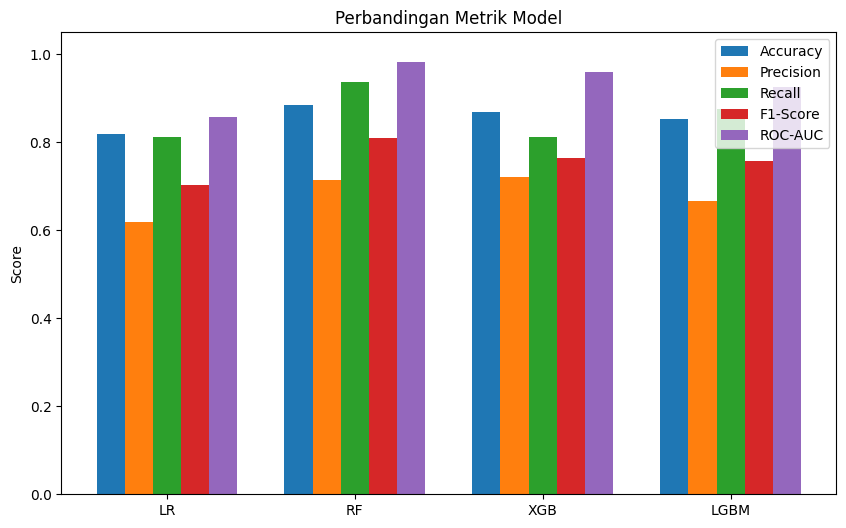

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Set posisi dan lebar bar
models = df_results["Model"]
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
x = np.arange(len(models))
width = 0.15

# Plot setiap metrik
plt.figure(figsize=(10,6))
for i, metric in enumerate(metrics):
    plt.bar(x + i*width, df_results[metric], width=width, label=metric)

plt.xticks(x + width*2, models)
plt.ylabel("Score")
plt.title("Perbandingan Metrik Model")
plt.ylim(0,1.05)  # Semua skala 0–1
plt.legend()
plt.show()


In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()


In [24]:
from sklearn.metrics import RocCurveDisplay

def plot_roc(model, X_test, y_test, model_name):
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:,1]
    else:
        y_score = model.decision_function(X_test)

    RocCurveDisplay.from_predictions(y_test, y_score)
    plt.title(f"ROC Curve - {model_name}")
    plt.show()


In [25]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, model_name):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Score")
    plt.plot(train_sizes, test_mean, 'o-', color="red", label="Validation Score")
    plt.title(f"Learning Curve - {model_name}")
    plt.xlabel("Training Size")
    plt.ylabel("Accuracy")
    plt.ylim(0,1.05)
    plt.grid(True)
    plt.legend()
    plt.show()


In [26]:
output_dir = "/content/drive/MyDrive/Tesis/Fix FE CV/Classic Clasifiers/Tuned Model/"
os.makedirs(output_dir, exist_ok=True)

for name, model in best_models.items():
    path = f"{output_dir}/{name}_tuned.pkl"
    joblib.dump(model, path)
    print("Saved:", path)


Saved: /content/drive/MyDrive/Tesis/Fix FE CV/Classic Clasifiers/Tuned Model//LR_tuned.pkl
Saved: /content/drive/MyDrive/Tesis/Fix FE CV/Classic Clasifiers/Tuned Model//RF_tuned.pkl
Saved: /content/drive/MyDrive/Tesis/Fix FE CV/Classic Clasifiers/Tuned Model//XGB_tuned.pkl
Saved: /content/drive/MyDrive/Tesis/Fix FE CV/Classic Clasifiers/Tuned Model//LGBM_tuned.pkl


+PR untuk base model buat pipeline+smote

In [27]:
import shap
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans

def generate_shap(
    model,
    X_train,
    X_test,
    feature_names,
    model_name="Model",
    top_n=10,
    output_dir="/content/drive/MyDrive/Tesis/FE CV/SHAP_Automatic"
):

    # --- FIX 1: pastikan feature_names dalam list agar .index() tidak error ---
    feature_names = list(feature_names)

    os.makedirs(output_dir, exist_ok=True)
    print(f"\n=== Membuat SHAP untuk {model_name} ===")

    # --- Pastikan X_test dataframe ---
    if isinstance(X_test, np.ndarray):
        X_test_df = pd.DataFrame(X_test, columns=feature_names)
    else:
        X_test_df = X_test.copy()

    # ------------------------------------------------
    # 1. PILIH EXPLAINER OTOMATIS
    # ------------------------------------------------
    try:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer(X_test_df)
        print("✔ TreeExplainer digunakan")
    except:
        explainer = shap.Explainer(model.predict, X_train)
        shap_values = explainer(X_test_df)
        print("✔ Explainer umum digunakan (non-tree model)")

    # --- SHAP values universal format ---
    try:
        sv = shap_values.values
    except:
        sv = np.array(shap_values)

    # ------------------------------------------------
    # 2. SUMMARY PLOT
    # ------------------------------------------------
    plt.figure()
    shap.summary_plot(sv, X_test_df, feature_names=feature_names, show=False)
    plt.savefig(f"{output_dir}/SHAP_Summary_{model_name}.png", bbox_inches="tight")
    plt.close()

    # ------------------------------------------------
    # 3. BAR PLOT
    # ------------------------------------------------
    plt.figure()
    shap.summary_plot(sv, X_test_df, feature_names=feature_names, plot_type="bar", show=False)
    plt.savefig(f"{output_dir}/SHAP_Bar_{model_name}.png", bbox_inches="tight")
    plt.close()

    # ------------------------------------------------
    # 4. WATERFALL (Sample 0)
    # ------------------------------------------------
    try:
        plt.figure()
        shap.plots.waterfall(shap_values[0])
        plt.savefig(f"{output_dir}/SHAP_Waterfall_{model_name}.png", bbox_inches="tight")
        plt.close()
    except Exception as e:
        print("✘ Waterfall Error:", e)

    # ------------------------------------------------
    # 5. FORCE PLOT SELURUH PASIEN
    # ------------------------------------------------
    print("✔ Membuat force plot untuk seluruh pasien...")

    shap.initjs()

    try:
        base_value = explainer.expected_value
        if isinstance(base_value, (list, np.ndarray)):
            base_value = base_value[1]  # binary classification
    except:
        base_value = np.mean(model.predict(X_train))

    force_dir = f"{output_dir}/ForcePlots_{model_name}"
    os.makedirs(force_dir, exist_ok=True)

    for i in range(len(X_test_df)):
        try:
            fp = shap.force_plot(
                base_value,
                sv[i],
                X_test_df.iloc[i],
                feature_names=feature_names,
                matplotlib=False
            )
            shap.save_html(f"{force_dir}/Force_{model_name}_Sample{i}.html", fp)
        except:
            pass

    print(f"✔ {len(X_test_df)} force plot dibuat")

    # ------------------------------------------------
    # 6. TOP-N FEATURES
    # ------------------------------------------------
    abs_shap = np.abs(sv).mean(axis=0)
    top_idx = np.argsort(abs_shap)[::-1][:top_n]
    top_features = [feature_names[i] for i in top_idx]
    top_imp = abs_shap[top_idx]

    df_top = pd.DataFrame({"Feature": top_features, "Importance": top_imp})
    df_top.to_csv(f"{output_dir}/TOP_{top_n}_Features_{model_name}.csv", index=False)

    # ------------------------------------------------
    # 7. DEPENDENCE PLOT
    # ------------------------------------------------
    dep_dir = f"{output_dir}/Dependence_{model_name}"
    os.makedirs(dep_dir, exist_ok=True)

    for f in top_features:
        safe_f = f.replace("/", "_").replace("\\", "_").replace(" ", "_")
        plt.figure()
        shap.dependence_plot(f, sv, X_test_df, show=False)
        plt.savefig(f"{dep_dir}/Dependence_{model_name}_{safe_f}.png", bbox_inches="tight")
        plt.close()

    print("✔ Dependence plot selesai")

    # ------------------------------------------------
    # 8. ANALISIS OTOMATIS FITUR
    # ------------------------------------------------
    analysis_lines = []
    for feat, imp in zip(top_features, top_imp):
        idx = feature_names.index(feat)   # sekarang aman!
        mean_effect = np.mean(sv[:, idx])
        direction = "MENINGKATKAN risiko" if mean_effect > 0 else "MENURUNKAN risiko"
        analysis_lines.append(
            f"{feat}: kontribusi rata-rata {mean_effect:.4f} → {direction}."
        )

    with open(f"{output_dir}/Feature_Analysis_{model_name}.txt", "w") as f:
        f.write("\n".join(analysis_lines))

    print("✔ Analisis fitur otomatis selesai")

    # ------------------------------------------------
    # 9. INTERACTION VALUES
    # ------------------------------------------------
    try:
        print("✔ Menghitung SHAP Interaction Values...")
        explainer_inter = shap.TreeExplainer(model)
        interaction_values = explainer_inter.shap_interaction_values(X_test_df)

        plt.figure()
        shap.summary_plot(interaction_values, X_test_df, show=False)
        plt.savefig(f"{output_dir}/Interaction_Summary_{model_name}.png", bbox_inches="tight")
        plt.close()

        mean_inter = np.abs(interaction_values).mean(axis=0)
        np.fill_diagonal(mean_inter, 0)

        pairs = []
        for i in range(len(feature_names)):
            for j in range(i+1, len(feature_names)):
                pairs.append((feature_names[i], feature_names[j], mean_inter[i, j]))

        df_pairs = pd.DataFrame(pairs, columns=["Feature_1", "Feature_2", "Interaction"])
        df_pairs = df_pairs.sort_values("Interaction", ascending=False).head(20)
        df_pairs.to_csv(f"{output_dir}/Top_Interaction_Pairs_{model_name}.csv", index=False)

        print("✔ Interaction values selesai")
    except Exception as e:
        print("✘ Interaction error:", e)

    # ------------------------------------------------
    # 10. CLUSTERING SHAP
    # ------------------------------------------------
    try:
        print("✔ Membuat SHAP Clustering...")

        kmeans = KMeans(n_clusters=3, random_state=42)
        clusters = kmeans.fit_predict(sv)

        result_df = X_test_df.copy()
        result_df["SHAP_Cluster"] = clusters
        result_df.to_csv(f"{output_dir}/SHAP_Clusters_{model_name}.csv", index=False)

        plt.figure()
        plt.scatter(sv[:, top_idx[0]], sv[:, top_idx[1]], c=clusters)
        plt.xlabel(top_features[0])
        plt.ylabel(top_features[1])
        plt.title(f"SHAP Clustering {model_name}")
        plt.savefig(f"{output_dir}/SHAP_Clustering_{model_name}.png", bbox_inches="tight")
        plt.close()

        print("✔ SHAP clustering selesai")
    except Exception as e:
        print("✘ Clustering error:", e)

    print(f"=== SHAP {model_name} SELESAI ===")



=== Membuat SHAP untuk LGBM ===


PermutationExplainer explainer: 62it [00:31,  1.45it/s]


✔ Explainer umum digunakan (non-tree model)


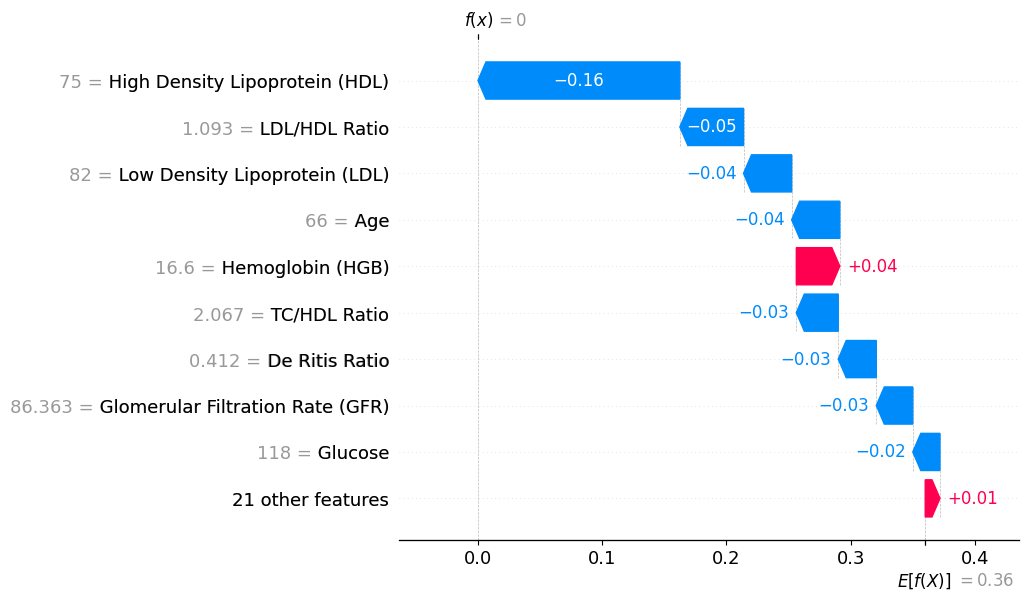

✔ Membuat force plot untuk seluruh pasien...


✔ 61 force plot dibuat
✔ Dependence plot selesai
✔ Analisis fitur otomatis selesai
✔ Menghitung SHAP Interaction Values...
✘ Interaction error: Model type not yet supported by TreeExplainer: <class 'imblearn.pipeline.Pipeline'>
✔ Membuat SHAP Clustering...
✔ SHAP clustering selesai
=== SHAP LGBM SELESAI ===


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [28]:
# Ambil nama fitur dari dataframe asli
feature_names = df.drop("Gallstone Status", axis=1).columns.tolist()

# Jalankan SHAP
generate_shap(
    best_models["LGBM"],
    X_train,
    X_test,
    feature_names,
    model_name="LGBM",
    top_n=20
)


In [29]:
print(best_models.keys())


dict_keys(['LR', 'RF', 'XGB', 'LGBM'])


In [30]:
print(models.keys())

RangeIndex(start=0, stop=4, step=1)


In [31]:
param_space = {
    "LR": {
        "model__C": [0.01, 0.1, 1, 10, 50, 100],
        "model__solver": ["lbfgs", "liblinear"]
    },

    "RF": {
    "model__n_estimators": [200, 300],#500
    "model__max_depth": [3, 5, 7,10],#10
    "model__min_samples_split": [5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
  },

    "XGB": {
    "model__n_estimators": [200, 300, 400],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 4, 5],
    "model__subsample": [0.7, 0.8, 0.9],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__reg_alpha": [0, 0.1, 0.5],
    "model__reg_lambda": [1, 1.5, 2]
    },

    "LGBM": {
        "model__n_estimators": [200, 300, 500],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [-1, 3, 5, 7],
        "model__num_leaves": [20, 31, 50]
    }
}


LR_base
RF_base
XGB_base
LGBM_base
LR_tuned
RF_tuned
XGB_tuned
LGBM_tuned
...
